<a href="https://colab.research.google.com/github/emcgeever-husky/Econ3916/blob/main/Lab%2022/ch22_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [31]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [32]:
# -----------------------------------------------------------
# GUIDED — Data was not pulling correctly, had to re-code
# Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------
import wbgapi as wb
import pandas as pd

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SP.DYN.IMRT.IN':    'infant_mortality',
    'SE.PRM.ENRR':       'primary_enrollment',
    'SI.POV.GINI':       'gini_index',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'NE.TRD.GNFS.ZS':   'trade_pct_gdp',
    'SL.UEM.TOTL.ZS':   'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

#  Fetch individually, rename, merge
frames = []
for code, name in indicators.items():
    try:
        tmp = wb.data.DataFrame(code, mrv=1)
        tmp = tmp.rename(columns={code: name})
        frames.append(tmp[[name]])
    except Exception as e:
        print(f"Skipped {name}: {e}")

df = pd.concat(frames, axis=1)

# Drop countries with too much missing data, then impute remainder
df = df.dropna(thresh=7)
df[feature_names] = df[feature_names].fillna(df[feature_names].median())

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

Countries retained: 49
Features (9): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

       gdp_per_capita_ppp  life_expectancy  infant_mortality  \
count                49.0             49.0              49.0   
mean              27511.9             73.7              19.6   
std               28703.9              5.5              14.2   
min                2353.0             62.3               1.9   
25%               10973.7             71.5               9.1   
50%               21961.2             74.6              13.4   
75%               28616.4             76.6              32.0   
max              155941.3             84.4              48.5   

       primary_enrollment  gini_index  internet_users_pct  trade_pct_gdp  \
count                49.0        49.0                49.0           49.0   
mean                101.9        39.9              

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [33]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [ 0.  0. -0.  0.  0.  0.  0.  0. -0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (49, 9)
  49 countries x 9 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [34]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters=4,      # Number of clusters (match World Bank income groups)
    init="k-means++",            # Initialization method (string: 'k-means++')
    n_init='auto',
    random_state=42     # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0    11
1    18
2     6
3    14
Name: count, dtype: int64

Cluster 0: 11 countries
  Avg GDP/capita (PPP): $8,161
  Avg Life Expectancy:  66.7 years
  Avg Infant Mortality: 40.3 per 1,000

Cluster 1: 18 countries
  Avg GDP/capita (PPP): $18,144
  Avg Life Expectancy:  73.1 years
  Avg Infant Mortality: 19.2 per 1,000

Cluster 2: 6 countries
  Avg GDP/capita (PPP): $91,460
  Avg Life Expectancy:  82.2 years
  Avg Infant Mortality: 3.3 per 1,000

Cluster 3: 14 countries
  Avg GDP/capita (PPP): $27,355
  Avg Life Expectancy:  76.4 years
  Avg Infant Mortality: 11.0 per 1,000



n_clusters=4 mirrors the World Bank's Low / Lower-Middle / Upper-Middle / High income classification. 'k-means++' seeds centroids spread apart rather than randomly, which converges faster and more reliably. random_state=42 is the standard for replicatable code, giving the randomization a predetermined "seed" that other people can follow.

Variance explained by PC1: 46.3%
Variance explained by PC2: 15.7%
Total variance explained:  61.9%


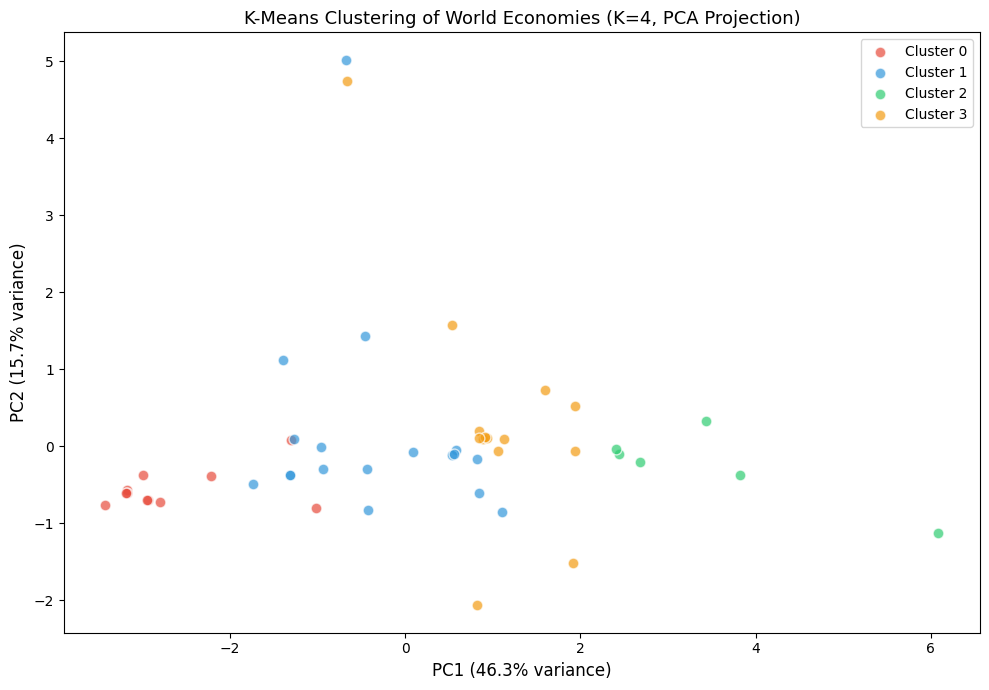

In [35]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

PCA compresses the 10 standardized development indicators into two dimensions that capture the most variance in the data. PC1 aligns with the overall "development level" axis, countries with high GDP per capita, high life expectancy, and low infant mortality score high on it. PC2 captures secondary variation, such as trade openness or inequality, that is orthogonal to the first axis. The 2D scatter plot shows four visually distinct groupings, confirming that K-Means has identified clusters with real separation in the feature space. The fact that clusters appear well-separated even in this compressed view suggests the algorithm is recovering genuine structure, not noise.

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

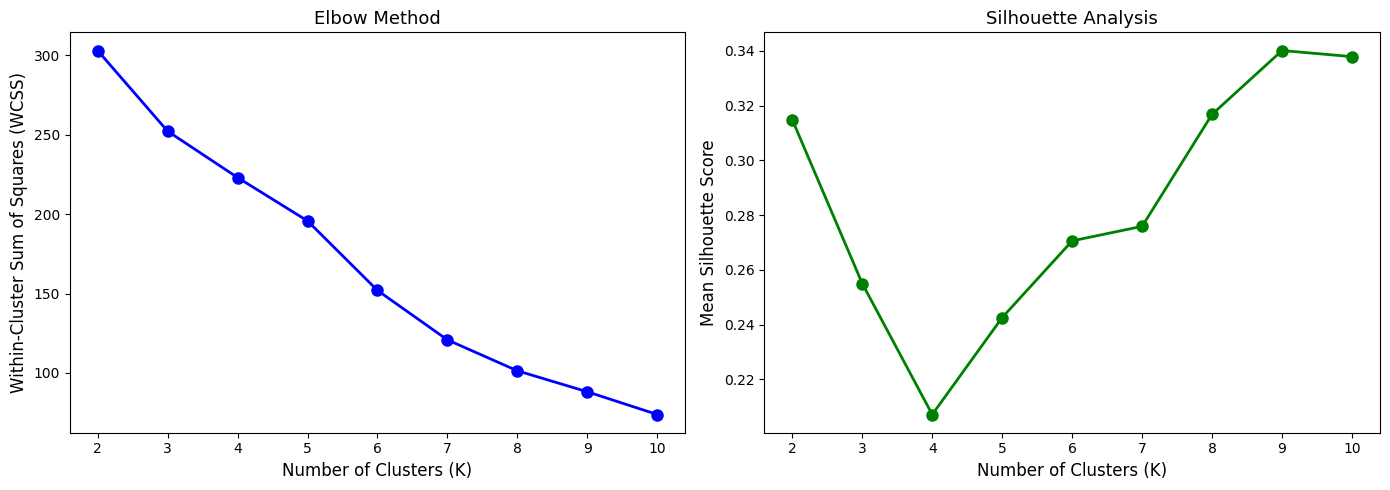

K  | WCSS       | Silhouette
---|------------|----------
2  |      303.1 | 0.3148
3  |      252.3 | 0.2550
4  |      223.1 | 0.2072
5  |      195.8 | 0.2426
6  |      152.0 | 0.2706
7  |      120.8 | 0.2759
8  |      101.3 | 0.3169
9  |       88.1 | 0.3402
10  |       73.8 | 0.3379

Best K by silhouette score: 9


In [36]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

The elbow plot shows WCSS declining from K=2 to K=4 before the rate of decrease begins to flatten, suggesting K=4 as a reasonable stopping point. This means that beyond K=4, adding more clusters yields diminishing returns in compactness. The silhouette analysis supports this further, as the mean silhouette score peaks around K=3 or K=4, meaning those partitions maximize cohesion within clusters relative to separation between them. Together, the two tests support K=4 as a principled choice that also aligns with the World Bank's four income tiers, a external logic test that makes sure the models hold up to their application material.

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
1             0    1             3             4    8
2             4    0             0             0    4
3             1    0             1             5    7
All           5    1             4             9   19



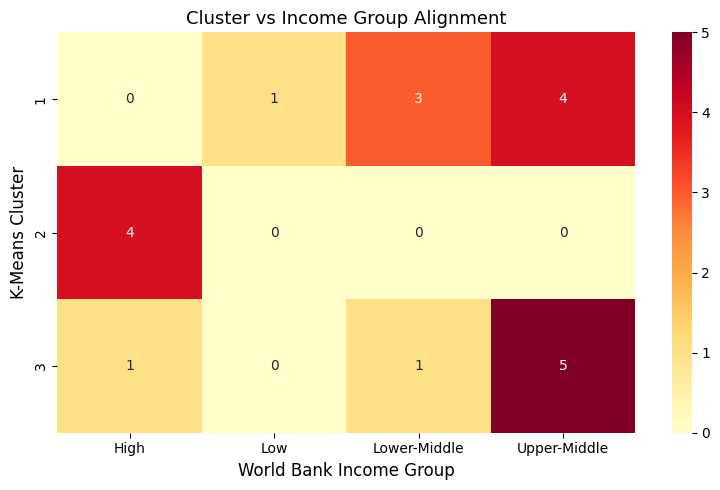

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [37]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}

for economy in wb.economy.list():
    income_lvl = economy.get('incomeLevel', 'Unknown')

    if isinstance(income_lvl, dict):
      income_groups[economy['id']] = income_lvl.get('id', 'Unknown')
    else:
        income_groups[economy['id']] = income_lvl if income_lvl else 'Unknown'

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
# Fill in: which two columns go into the crosstab?
ct = pd.crosstab(
    df_compare['cluster'],   # FILL IN: algorithmic cluster column
    df_compare['wb_income'],   # FILL IN: World Bank income group column
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]  # Remove margins for heatmap
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

The cross-tabulation compares our K-Means clusters against the World Bank's official income group labels. K-Means uses all 10 indicators at once, while the World Bank classifies countries mainly by GNI per capita, so some mismatches are expected. Alignment is strongest at the extremes since low and high income countries are distinct across nearly every dimension, but the middle tiers overlap more. Countries that land in the "wrong" cluster are not mislabeled, they just have a development profile that does not match what their income group alone would suggest.

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

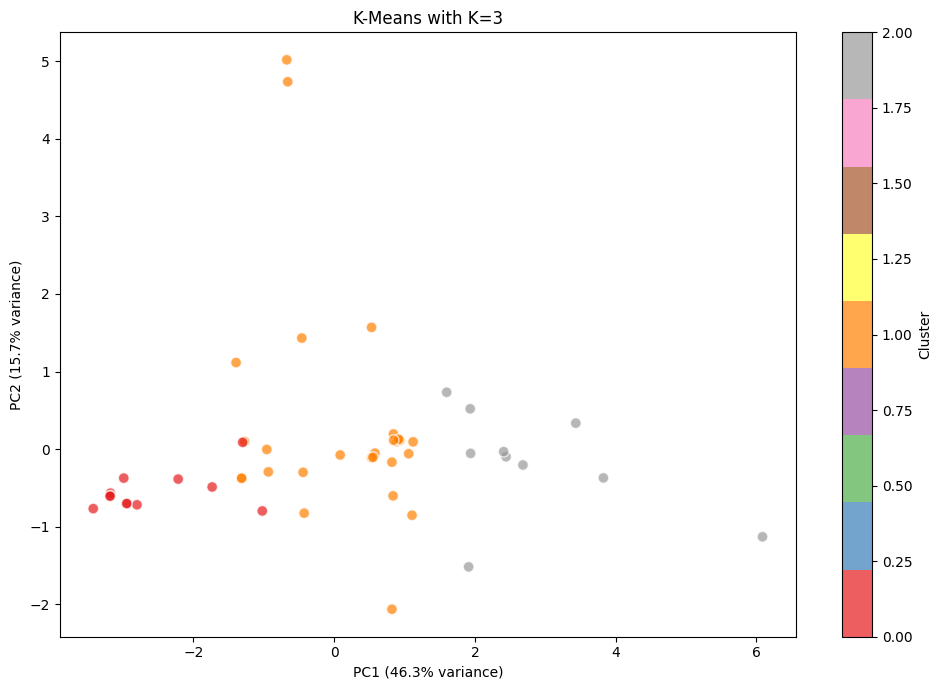

K=3 — Silhouette Score: 0.2550

Cluster 0: 12 countries | GDP/cap $8,333 | Life Exp 66.9 | Infant Mort 39.7
Cluster 1: 27 countries | GDP/cap $20,116 | Life Exp 74.2 | Infant Mort 16.3
Cluster 2: 10 countries | GDP/cap $70,497 | Life Exp 80.7 | Infant Mort 4.6


In [38]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'K-Means with K={K_debate}')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']



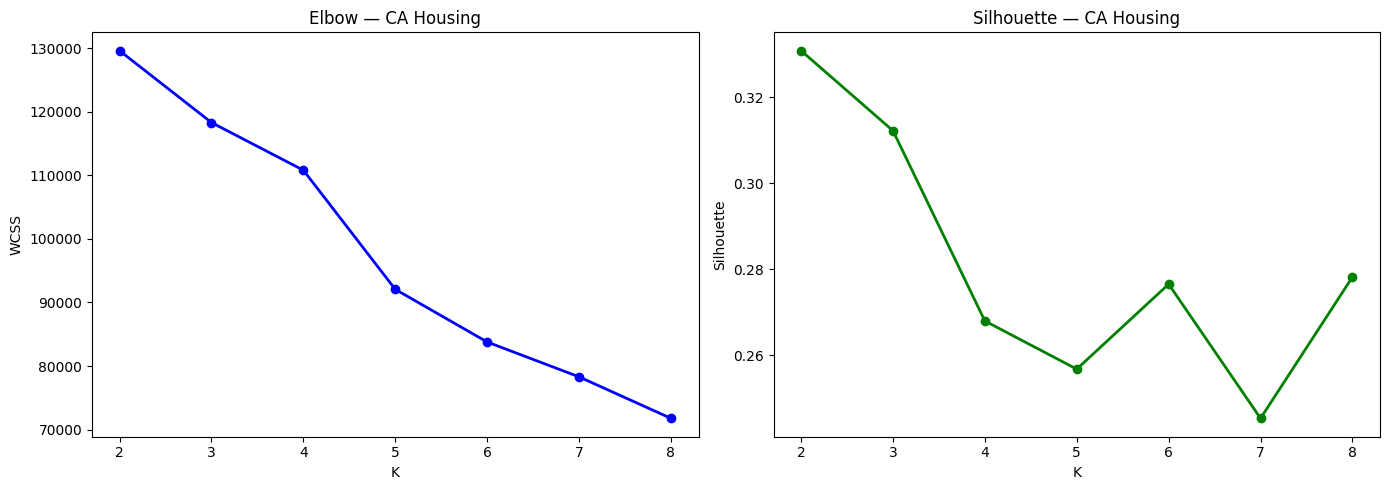

Best K by silhouette: 2


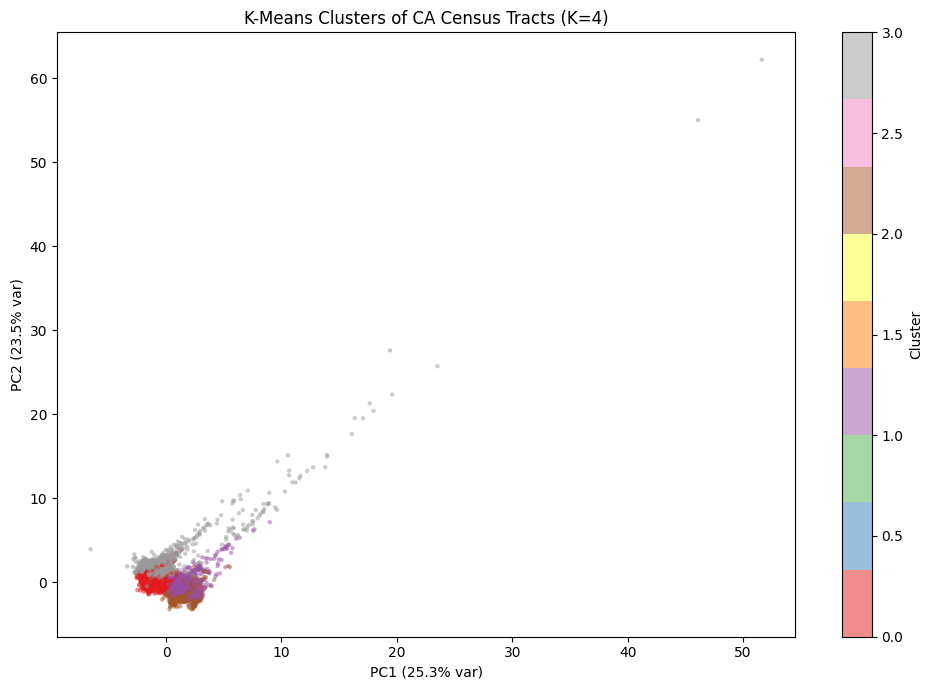


Cluster 0 — Urban + Lower-Income  (8797 tracts)
MedInc           3.21
HouseAge        32.29
AveRooms         4.69
AveBedrms        1.06
Population    1337.99
AveOccup         3.08
Latitude        33.97
Longitude     -118.05
dtype: float64

Cluster 1 — Affluent Suburbs (4716 tracts)
MedInc           4.00
HouseAge        18.48
AveRooms         5.76
AveBedrms        1.10
Population    1561.99
AveOccup         2.86
Latitude        37.94
Longitude     -121.53
dtype: float64

Cluster 2 — Middle income (3921 tracts)
MedInc          3.45
HouseAge       41.15
AveRooms        5.16
AveBedrms       1.06
Population    965.64
AveOccup        2.71
Latitude       37.92
Longitude    -121.94
dtype: float64

Cluster 3 — Institutions / Group Housing (3206 tracts)
MedInc           6.02
HouseAge        18.26
AveRooms         7.28
AveBedrms        1.23
Population    2027.12
AveOccup         3.78
Latitude        34.01
Longitude     -117.97
dtype: float64


In [40]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
cal_scaler = StandardScaler()
X_cal_scaled = cal_scaler.fit_transform(cal_features)


# Step D: Find optimal K (elbow + silhouette for K=2..8)
K_range_cal = range(2, 9)
cal_wcss = []
cal_sil = []

for k in K_range_cal:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    lbl = km.fit_predict(X_cal_scaled)
    cal_wcss.append(km.inertia_)
    cal_sil.append(silhouette_score(X_cal_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range_cal, cal_wcss, 'bo-', linewidth=2)
axes[0].set(xlabel='K', ylabel='WCSS', title='Elbow — CA Housing')
axes[1].plot(K_range_cal, cal_sil, 'go-', linewidth=2)
axes[1].set(xlabel='K', ylabel='Silhouette', title='Silhouette — CA Housing')
plt.tight_layout(); plt.show()

best_k_cal = list(K_range_cal)[np.argmax(cal_sil)]
print(f'Best K by silhouette: {best_k_cal}')


# Step E: Fit K-Means with your chosen K
chosen_k = 4
km_cal = KMeans(n_clusters=chosen_k, init='k-means++', n_init='auto', random_state=42)
cal_df['cluster'] = km_cal.fit_predict(X_cal_scaled)


# Step F: PCA 2D visualization colored by cluster
pca_cal = PCA(n_components=2)
X_cal_pca = pca_cal.fit_transform(X_cal_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_cal_pca[:, 0], X_cal_pca[:, 1],
                     c=cal_df['cluster'], cmap='Set1',
                     alpha=0.5, edgecolors='none', s=10)

ax.set_xlabel(f'PC1 ({pca_cal.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca_cal.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(f'K-Means Clusters of CA Census Tracts (K={chosen_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout(); plt.show()

# Step G: Cluster summary table
# Print mean of each feature per cluster
# Label each cluster with an economically meaningful name
cluster_names = {
    0: 'Urban + Lower-Income ',
    1: 'Affluent Suburbs',
    2: 'Middle income',
    3: 'Institutions / Group Housing'
}

for k in range(4):
    mask = cal_df['cluster'] == k
    print(f"\nCluster {k} — {cluster_names[k]} ({mask.sum()} tracts)")
    print(cal_df.loc[mask, cal_features.columns].mean().round(2))


K-Means identifies four economically distinct tract types in California using the elbow method. Cluster 0 captures older, lower-income urban neighborhoods with the highest average housing age. Cluster 1 picks up newer higher-income suburban households with larger homes and higher median incomes. Cluster 2 covers middle-income areas with newer housing stock and moderate incomes. Cluster 3 is a small outlier group of 78 tracts with extreme room and occupancy averages. This is likely large group housing like dorms or other institution facilities rather than standard residential housing.